# Podstawowy ruch — symulowany robot JetBot 🤖

Cześć! To jest notatnik Jupyter — taki interaktywny dokument, w którym
możesz **czytać tekst i jednocześnie uruchamiać kod**. Każdy szary blok
poniżej to *komórka z kodem*. Żeby uruchomić komórkę, kliknij ją i naciśnij
**Shift + Enter** (albo strzałkę "play" po lewej).

W tym notatniku **nauczysz się sterować robotem** — ale nie prawdziwym,
tylko jego **wersją w komputerze** (symulacją). Dzięki temu nie potrzebujesz
żadnego sprzętu, wystarczy przeglądarka.

Ten notatnik jest oparty na oryginalnym samouczku JetBota od firmy NVIDIA
(robot edukacyjny używany w szkołach). Polecenia, których się tu nauczysz,
będą działały dokładnie tak samo na prawdziwym JetBocie, gdybyś kiedyś
takiego miał:

```python
robot.forward(0.5)   # jedź do przodu z połową maksymalnej prędkości
robot.left(0.3)      # obracaj się w lewo
robot.stop()         # zatrzymaj się
```

> **Jak to uruchomić w Google Colab:** wejdź na
> [colab.research.google.com](https://colab.research.google.com), wybierz
> *Plik → Prześlij notatnik* (*File → Upload notebook*) i wskaż ten plik.
> Potem uruchamiaj komórki po kolei klawiszami **Shift + Enter**.


## 1. Przygotowanie

Tę komórkę uruchamiamy raz, na początku. Wczytuje ona biblioteki
(czyli zestawy gotowych narzędzi), z których będziemy korzystać.

Nie musisz rozumieć każdej linijki — to taki "import zestawu pędzli zanim
zaczniemy malować".


In [ ]:
# Standardowe biblioteki — wszystkie są już dostępne w Google Colab,
# nie trzeba ich osobno instalować.
import math, time, threading
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets
import traitlets
from traitlets import HasTraits, Float

# Włączamy obsługę interaktywnych elementów (suwaków, przycisków) w Colabie.
# Poza Colabem ten kawałek po prostu się pominie.
try:
    from google.colab import output as _colab_output
    _colab_output.enable_custom_widget_manager()
    print("✓ Działamy w Google Colab — obsługa widżetów włączona")
except ImportError:
    print("✓ Działamy w zwykłym Jupyterze / JupyterLab")

# Ta linijka mówi Jupyterowi, żeby rysował wykresy bezpośrednio w notatniku.
%matplotlib inline


✓ Działamy w Google Colab — obsługa widżetów włączona


## 2. Co to jest "symulowany robot"?

Nasz robot ma **dwa koła**, każde napędzane osobnym silniczkiem (taki
sam układ ma JetBot, ale też np. odkurzacze automatyczne). Taki sposób
napędu nazywa się **napędem różnicowym** (po angielsku *differential
drive*).

Cały trik polega na tym, że obracając kołami z różnymi prędkościami,
robot porusza się w różny sposób:

| Lewe koło | Prawe koło | Co robi robot |
|---|---|---|
| do przodu | do przodu | jedzie prosto |
| do tyłu | do tyłu | cofa się |
| do tyłu | do przodu | obraca się w lewo (w miejscu) |
| do przodu | do tyłu | obraca się w prawo (w miejscu) |
| wolno do przodu | szybko do przodu | jedzie po łuku w lewo |

W kolejnej komórce **tworzymy** takiego wirtualnego robota. Nie musisz rozumieć
każdej linijki — najważniejsze jest to, że na końcu mamy **klasę** o nazwie
`Robot`, której będziemy używać tak, jakby to był prawdziwy robot.

> **Słowniczek:**
> * **klasa** — w Pythonie to taki "przepis" na to, jak coś działa
>   (jak ma się zachowywać samochód, drzewo, robot...).
> * **obiekt** — konkretna rzecz stworzona z przepisu (jeden konkretny
>   samochód, jedno konkretne drzewo).
> * **wątek (thread)** — coś, co dzieje się w tle, równolegle do
>   głównego programu. U nas w tle cały czas "kręcą się koła" robota.


In [ ]:
class Motor(HasTraits):
    """Reprezentuje jedno koło robota.

    Pole `value` to prędkość w zakresie od -1.0 (pełna prędkość do tyłu)
    do +1.0 (pełna prędkość do przodu)."""
    value = Float(0.0)


class Robot:
    """Symulowany robot z napędem różnicowym.

    Ma takie same metody (polecenia) jak prawdziwy JetBot:
    forward, backward, left, right, set_motors, stop.
    """

    # Parametry fizyczne robota — prawdziwy JetBot ma podobne wartości.
    WHEEL_BASE = 0.12   # odległość między kołami w metrach (12 cm)
    MAX_SPEED  = 0.30   # prędkość przy `value` = 1.0  → 0,30 m/s

    def __init__(self):
        # Tworzymy dwa silniki: lewy i prawy.
        self.left_motor  = Motor()
        self.right_motor = Motor()

        # Pozycja robota w "świecie":
        #   x, y  — położenie (w metrach)
        #   theta — kierunek, w którym robot patrzy (w radianach)
        self.x, self.y, self.theta = 0.0, 0.0, 0.0

        # Lista punktów, przez które robot przejechał — żeby narysować ślad.
        self.trail = [(0.0, 0.0)]
        self._max_trail = 2000

        # Uruchamiamy fizykę w tle (osobny wątek), żeby robot
        # poruszał się płynnie, niezależnie od tego, co robisz w notatniku.
        self._lock      = threading.Lock()
        self._running   = True
        self._last_t    = time.time()
        self._thread    = threading.Thread(target=self._physics_loop, daemon=True)
        self._thread.start()

    # ----- "Fizyka" robota: obliczanie nowej pozycji ------------------
    def _physics_loop(self):
        """Pętla, która 50 razy na sekundę przelicza, gdzie jest robot.

        Wzory są proste:
          - prędkość liniowa  = średnia z prędkości obu kół
          - prędkość obrotowa = różnica prędkości kół / rozstaw kół
        """
        while self._running:
            now = time.time()
            dt  = now - self._last_t   # ile czasu minęło od ostatniego razu
            self._last_t = now

            with self._lock:
                # Prędkości kół w metrach na sekundę.
                vL = self.left_motor.value  * self.MAX_SPEED
                vR = self.right_motor.value * self.MAX_SPEED

                # Prędkość, z jaką robot się przesuwa, i z jaką się obraca.
                v     = 0.5 * (vL + vR)
                omega = (vR - vL) / self.WHEEL_BASE

                # Aktualizujemy pozycję i kierunek.
                self.theta += omega * dt
                self.x     += v * math.cos(self.theta) * dt
                self.y     += v * math.sin(self.theta) * dt

                # Zapamiętujemy nowy punkt śladu (jeśli robot się ruszył).
                last = self.trail[-1]
                if (self.x - last[0]) ** 2 + (self.y - last[1]) ** 2 > 1e-6:
                    self.trail.append((self.x, self.y))
                    if len(self.trail) > self._max_trail:
                        self.trail.pop(0)

            time.sleep(0.02)        # przerwa 20 ms → 50 razy/sekundę

    def get_pose(self):
        """Zwraca aktualne położenie i kierunek robota."""
        with self._lock:
            return self.x, self.y, self.theta, list(self.trail)

    # ----- Polecenia, których będziemy używać ------------------------
    def set_motors(self, left_speed, right_speed):
        """Ustawia prędkości obu kół niezależnie. Zakres: -1.0 do 1.0."""
        self.left_motor.value  = float(left_speed)
        self.right_motor.value = float(right_speed)

    def forward (self, speed=1.0): self.set_motors( speed,  speed)  # do przodu
    def backward(self, speed=1.0): self.set_motors(-speed, -speed)  # do tyłu
    def left    (self, speed=1.0): self.set_motors(-speed,  speed)  # obrót w lewo
    def right   (self, speed=1.0): self.set_motors( speed, -speed)  # obrót w prawo
    def stop    (self):            self.set_motors(0.0, 0.0)        # stop

    # ----- Pomocnicze (tylko dla symulacji) --------------------------
    def reset(self):
        """Zatrzymuje robota i przenosi go z powrotem do punktu (0, 0).
        Przydatne między eksperymentami, żeby wykresy były czytelne."""
        self.stop()
        with self._lock:
            self.x, self.y, self.theta = 0.0, 0.0, 0.0
            self.trail = [(0.0, 0.0)]


## 3. Funkcje do rysowania

Skoro robot jest wirtualny, musimy jakoś go **zobaczyć**. Dlatego
przygotowujemy trzy funkcje:

* `show()` — rysuje pojedyncze zdjęcie pokazujące, gdzie jest robot teraz.
* `animate(czas)` — nagrywa, co się dzieje przez kilka sekund, i odtwarza
  to jako film w komórce (jak GIF). To najfajniejsza opcja — *widzisz*, jak
  robot się porusza.
* `live(czas)` — pokazuje ruch "na żywo", w czasie rzeczywistym.

Niebieskie kółko to robot. **Czerwona strzałka** pokazuje, w którą stronę
patrzy. **Jasnoniebieska linia** to ślad — droga, którą już przejechał.


In [ ]:
def _draw(ax, x, y, theta, trail):
    """Rysuje robota i jego ślad na podanym wykresie."""
    ax.clear()
    # Ślad — linia po wszystkich punktach, przez które robot przejechał.
    if len(trail) > 1:
        xs, ys = zip(*trail)
        ax.plot(xs, ys, "-", color="#7fb3d5", linewidth=1.5, label="ślad")

    # Robot — niebieskie kółko.
    body = mpatches.Circle((x, y), 0.05, color="#2874a6", alpha=0.85, zorder=5)
    ax.add_patch(body)

    # Strzałka kierunku — pokazuje, w którą stronę patrzy robot.
    ax.arrow(x, y,
             0.08 * math.cos(theta), 0.08 * math.sin(theta),
             head_width=0.025, head_length=0.025,
             fc="#c0392b", ec="#c0392b", zorder=6)

    # Automatyczne dopasowanie zoomu, żeby cały ślad był widoczny.
    all_x = [p[0] for p in trail] + [x]
    all_y = [p[1] for p in trail] + [y]
    cx, cy = (max(all_x) + min(all_x)) / 2, (max(all_y) + min(all_y)) / 2
    half   = max(max(all_x) - min(all_x), max(all_y) - min(all_y), 0.6) / 2 + 0.2

    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
    ax.set_title(f"Symulowany JetBot  —  x={x:+.2f} m,  y={y:+.2f} m,  kąt={math.degrees(theta):+.0f}°")


def show():
    """Rysuje pojedyncze zdjęcie aktualnej pozycji robota."""
    x, y, theta, trail = robot.get_pose()
    fig, ax = plt.subplots(figsize=(6, 6))
    _draw(ax, x, y, theta, trail)
    plt.show()


def animate(duration=2.0, fps=20):
    """Nagrywa ruch robota przez `duration` sekund i odtwarza go jako film."""
    frames = []
    start = time.time()
    while time.time() - start < duration:
        frames.append(robot.get_pose())
        time.sleep(1.0 / fps)

    fig, ax = plt.subplots(figsize=(6, 6))

    def _update(i):
        _draw(ax, *frames[i])
        return []

    anim = FuncAnimation(fig, _update, frames=len(frames),
                         interval=1000 / fps, blit=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())


def live(duration=2.0, fps=10):
    """Pokazuje ruch na żywo: czyści wykres i rysuje nowy w pętli."""
    end = time.time() + duration
    while time.time() < end:
        clear_output(wait=True)
        show()
        time.sleep(1.0 / fps)


## 4. Tworzymy robota

Linijka poniżej **tworzy** naszego robota. Od tej chwili możemy się do niego
odwoływać przez nazwę `robot` (jak imię).

Wywołanie `show()` od razu narysuje, gdzie robot się znajduje (na razie
w punkcie startowym: x=0, y=0, patrząc w prawo).


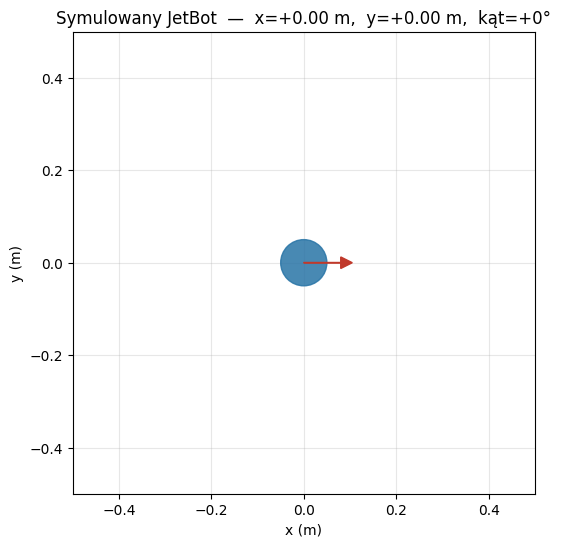

In [ ]:
robot = Robot()
show()


## 5. Pierwsze polecenia

Spróbujmy obrócić robota **w lewo** z prędkością 30% maksymalnej (czyli
`speed=0.3`) przez 2 sekundy, a potem go zatrzymać.

Co robi każda linijka:

* `robot.left(speed=0.3)` — zaczyna obracać się w lewo.
* `time.sleep(2.0)` — program czeka 2 sekundy (robot dalej się obraca).
* `robot.stop()` — robot się zatrzymuje.
* `show()` — rysujemy, co się stało.

> **Uwaga:** w prawdziwym świecie ta komenda spowodowałaby ruch robota.
> U nas to tylko punkcik na wykresie — możesz eksperymentować bez obaw 😄


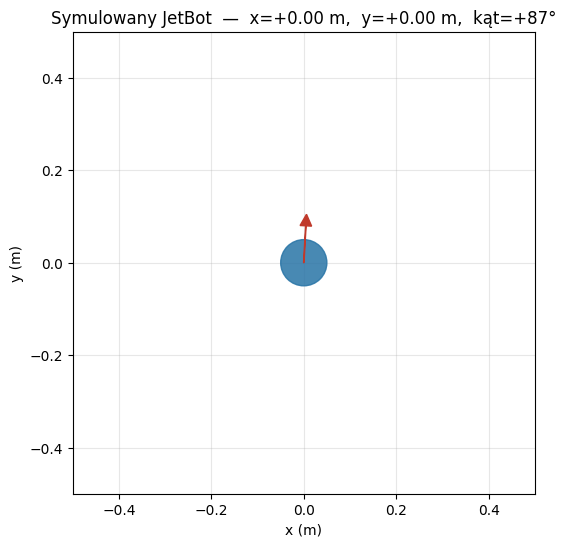

In [ ]:
robot.left(speed=0.3)
time.sleep(0.2)
robot.stop()
show()


Spróbuj teraz innych poleceń. `reset()` cofa robota do punktu początkowego,
żeby wykres był czytelny.


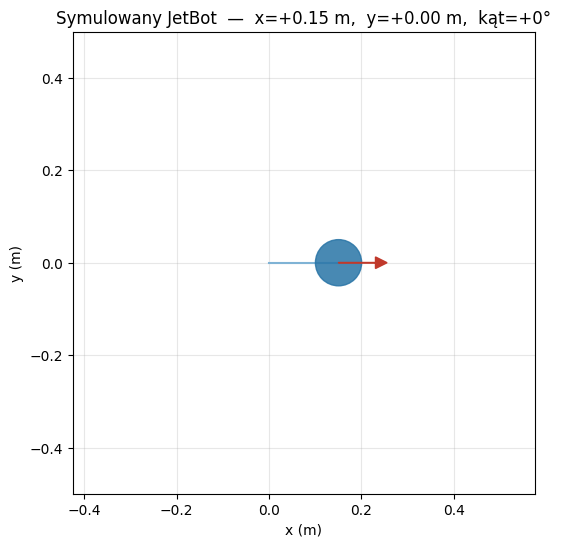

In [ ]:
robot.reset()

robot.forward(0.5)   # jedź do przodu z połową maksymalnej prędkości
time.sleep(1.0)      # przez 1 sekundę
robot.stop()
show()


A teraz dłuższy układ ruchów — taki mały taniec robota. Spróbuj zmienić
liczby i zobacz, co się stanie!


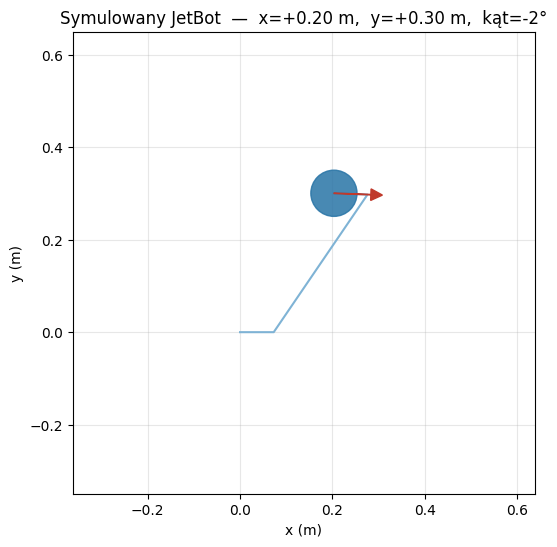

In [ ]:
robot.reset()

# Najpierw do przodu, potem w lewo, potem znowu do przodu...
robot.forward(0.4);  time.sleep(0.6)
robot.left(0.4);     time.sleep(0.5)
robot.forward(0.4);  time.sleep(3.0)
robot.right(0.4);    time.sleep(0.5)
robot.backward(0.4); time.sleep(0.6)
robot.stop()
show()


## 6. Sterowanie każdym kołem osobno

Do tej pory używaliśmy gotowych poleceń (`forward`, `left`...). Ale możemy
też sterować **każdym kołem osobno** — używając `set_motors(lewe, prawe)`.

W komórce poniżej lewe koło kręci się wolniej (0.3) niż prawe (0.6),
więc robot pojedzie **po łuku w lewo** — tak jak rower, kiedy jedna pedałka
kręci się szybciej.


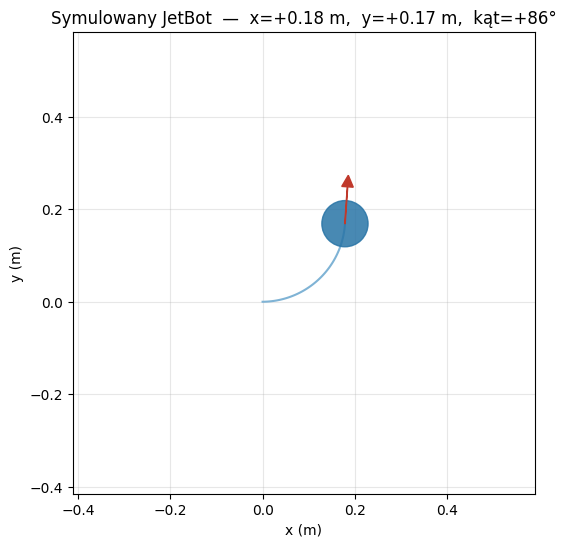

In [ ]:
robot.reset()
robot.set_motors(0.3, 0.6)   # lewe wolniej, prawe szybciej → łuk w lewo
time.sleep(2.0)
robot.stop()
show()


Można też zmieniać prędkości kół bezpośrednio, przez `left_motor.value`
i `right_motor.value`. To samo, co `set_motors`, tylko zapisane inaczej:


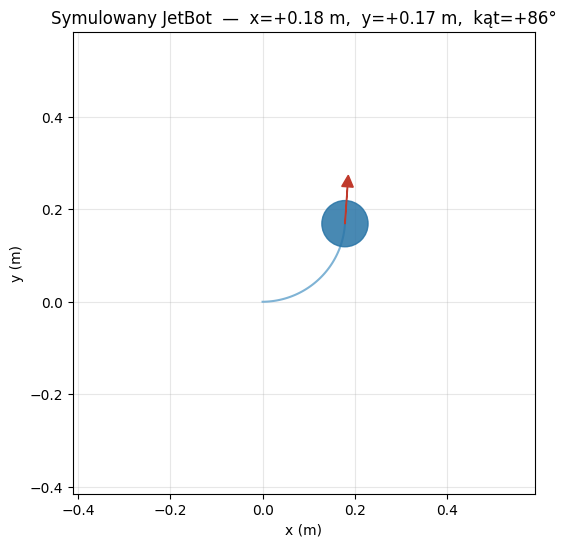

In [ ]:
robot.reset()
robot.left_motor.value  = 0.3
robot.right_motor.value = 0.6
time.sleep(2.0)
robot.left_motor.value  = 0.0
robot.right_motor.value = 0.0
show()


## 7. Animacja na żywo 🎬

Statyczne wykresy są fajne, ale jeszcze fajniej jest **zobaczyć ruch**.
Funkcja `animate(czas)` nagrywa, co się dzieje przez podany czas, i pokazuje
to jako mały filmik (możesz go zatrzymać, przewinąć, puścić wolniej).

W komórce poniżej każemy robotowi jechać po łuku w lewo, jednocześnie
nagrywając przez 3 sekundy.


In [ ]:
robot.reset()
robot.set_motors(0.4, 0.7)     # delikatny łuk w lewo
clip = animate(duration=3.0)   # nagrywamy 3 sekundy
robot.stop()
clip                           # wyświetlamy nagranie


## 8. Sterowanie przyciskami

Zamiast pisać kod, możemy zrobić **panel sterowania z przyciskami** — jak
prawdziwy pilot. Każdy przycisk wykonuje krótki ruch i pokazuje wynik na
wykresie.


In [ ]:
# Wygląd przycisków.
button_layout = widgets.Layout(width='80px', height='50px', align_self='center')

# Tworzymy przyciski.
stop_b     = widgets.Button(description='stop',     button_style='danger',  layout=button_layout)
forward_b  = widgets.Button(description='przód',    layout=button_layout)
backward_b = widgets.Button(description='tył',      layout=button_layout)
left_b     = widgets.Button(description='lewo',     layout=button_layout)
right_b    = widgets.Button(description='prawo',    layout=button_layout)
reset_b    = widgets.Button(description='reset',    button_style='warning', layout=button_layout)

# Obszar, w którym będziemy rysować robota po każdym kliknięciu.
out = widgets.Output()

def _do(action_fn):
    """Pomocnik: wykonuje akcję i odświeża wykres."""
    def _handler(_change):
        action_fn()
        with out:
            clear_output(wait=True)
            show()
    return _handler

def _step(direction, speed=0.4, secs=0.5):
    """Krótki ruch w wybranym kierunku: rusz, poczekaj, stop."""
    direction(speed); time.sleep(secs); robot.stop()

# Łączymy przyciski z akcjami.
stop_b    .on_click(_do(lambda: robot.stop()))
forward_b .on_click(_do(lambda: _step(robot.forward)))
backward_b.on_click(_do(lambda: _step(robot.backward)))
left_b    .on_click(_do(lambda: _step(robot.left,  speed=0.3)))
right_b   .on_click(_do(lambda: _step(robot.right, speed=0.3)))
reset_b   .on_click(_do(lambda: robot.reset()))

# Układamy przyciski w kształcie krzyża (jak pad do gier).
pad = widgets.VBox([
    forward_b,
    widgets.HBox([left_b, stop_b, right_b]),
    backward_b,
    reset_b,
])
display(pad, out)


## 9. Telesterowanie — sterujesz robotem jak pilotem

**Telesterowanie** (po angielsku *teleoperation*) to sterowanie maszyną
na odległość. Spotykasz się z nim częściej niż myślisz:

* 🛩️ **drony** sterowane pilotem,
* 🤿 **roboty podwodne**, którymi badamy wraki i głębiny,
* 🏥 **roboty chirurgiczne** typu *da Vinci* — lekarz operuje pacjenta
  z drugiego pokoju, a czasem z drugiego miasta,
* 🚀 **łaziki marsjańskie** — sterowane z Ziemi, ale… o tym za chwilę.

W tej sekcji **Ty jesteś operatorem**. Twoje zadanie: doprowadzić robota
do **zielonej gwiazdki**. Sterowanie jest *ciągłe*: klikasz "przód" →
robot rusza i jedzie dalej; klikasz **STOP** → zatrzymuje się.

> **Wskazówka:** wykres odświeża się co ~0,3 s, więc widzisz, co robot
> robi praktycznie w czasie rzeczywistym. Łatwizna, prawda? W następnej
> sekcji już taka łatwa nie będzie 😉


In [ ]:
# Cel, do którego ma dojechać robot — zielona gwiazdka na wykresie.
TARGET = (0.5, 0.4)


def _draw_with_target(ax, x, y, theta, trail, target=TARGET):
    """Rysuje robota, ślad i cel z odległością do niego."""
    _draw(ax, x, y, theta, trail)
    ax.plot(*target, marker="*", color="#27ae60", markersize=28, zorder=7)
    ax.plot([x, target[0]], [y, target[1]], ":", color="#27ae60", alpha=0.5, linewidth=1.2)
    dist_cm = math.hypot(x - target[0], y - target[1]) * 100
    ax.text(0.02, 0.98, f"odległość do celu: {dist_cm:.0f} cm",
            transform=ax.transAxes, verticalalignment="top", fontsize=11,
            bbox=dict(boxstyle="round", facecolor="#fffbcc", alpha=0.95))


def show_teleop():
    x, y, theta, trail = robot.get_pose()
    fig, ax = plt.subplots(figsize=(6, 6))
    _draw_with_target(ax, x, y, theta, trail)
    plt.show()


# Zaczynamy z robotem w punkcie startowym.
robot.reset()

# Przyciski sterowania. Ciągłe: klik = silniki włączone, dopóki nie klikniesz STOP.
btn = widgets.Layout(width='90px', height='50px')
t_forward = widgets.Button(description='▲ przód', layout=btn)
t_back    = widgets.Button(description='▼ tył',   layout=btn)
t_left    = widgets.Button(description='◀ lewo',  layout=btn)
t_right   = widgets.Button(description='▶ prawo', layout=btn)
t_stop    = widgets.Button(description='■ STOP',  button_style='danger',  layout=btn)
t_reset   = widgets.Button(description='⟲ reset', button_style='warning', layout=btn)

t_forward.on_click(lambda _: robot.forward(0.3))
t_back   .on_click(lambda _: robot.backward(0.3))
t_left   .on_click(lambda _: robot.left(0.3))
t_right  .on_click(lambda _: robot.right(0.3))
t_stop   .on_click(lambda _: robot.stop())
t_reset  .on_click(lambda _: robot.reset())

# Obszar na wykres, który odświeża się sam w tle.
teleop_out = widgets.Output()

def _teleop_refresh():
    """Co ~0.3 s rysuje na nowo aktualną pozycję robota."""
    while True:
        with teleop_out:
            clear_output(wait=True)
            show_teleop()
        time.sleep(0.3)

threading.Thread(target=_teleop_refresh, daemon=True).start()

# Układ: pad sterowania po lewej, podgląd po prawej.
pad = widgets.VBox([
    t_forward,
    widgets.HBox([t_left, t_stop, t_right]),
    t_back,
    t_reset,
])
display(widgets.HBox([pad, teleop_out]))

print("Spróbuj dojechać do zielonej gwiazdki! Pamiętaj o STOP, gdy dojedziesz.")


## 12. Telesterowanie z opóźnieniem — łazik na Księżycu i Marsie 🌕🔴

W kosmosie *wszystko* trwa dłużej. Sygnały radiowe lecą z prędkością
światła — to **300 000 km/s**, brzmi szybko, ale przy odległościach
kosmicznych to wcale nie jest dużo:

| Cel | Odległość | Sygnał w jedną stronę | **Tam i z powrotem** |
|---|---|---|---|
| Stacja kosmiczna ISS | ~400 km | ~1,3 ms | ~2,7 ms |
| **🌕 Księżyc** | ~384 000 km | ~1,3 s | **~2,6 s** |
| **🔴 Mars** | 55–401 mln km | 3–22 min | **6–44 min** |

To znaczy, że kiedy operator na Ziemi naciska "przód", **robot dowiaduje
się o tym dopiero po pewnym czasie**. A operator widzi reakcję robota
dopiero po **kolejnym takim czasie** (sygnał musi wrócić z kamery).

### Dlatego *Curiosity* nie jest sterowany na żywo

Łazika **Curiosity** na Marsie nie da się sterować joystickiem. Inżynierowie
codziennie planują dla niego cały dzień pracy ("przejedź 5 metrów na
północ, zrób zdjęcie, zatrzymaj się przed kamieniem"), wysyłają taki plan
rano, a wieczorem łazik raportuje, co udało mu się zrobić. **To dlatego
robotyka kosmiczna tak bardzo zależy od autonomii** — robot musi sam
podejmować decyzje, bo na pomoc człowieka trzeba czekać kilkanaście minut.

W tej sekcji to **poczujesz na własnej skórze**. Spróbuj tego samego, co
przed chwilą — dojechać do gwiazdki — ale z opóźnieniem:

1. **Ziemia (0 s)** — łatwo, jak przed chwilą.
2. **Księżyc (2,6 s)** — trudniej, będziesz przesadzał i wracał.
3. **Mars (10 s)** — to opóźnienie jest **mocno skrócone** w porównaniu
   z prawdziwym Marsem (gdzie wynosi minuty), ale i tak prawie niemożliwe.


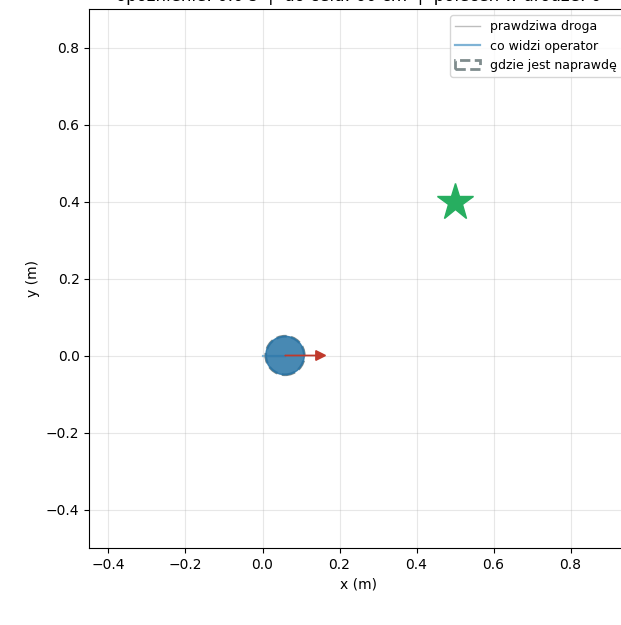

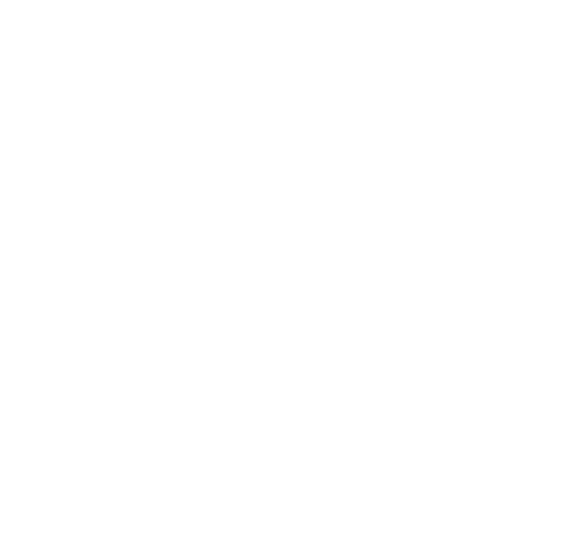

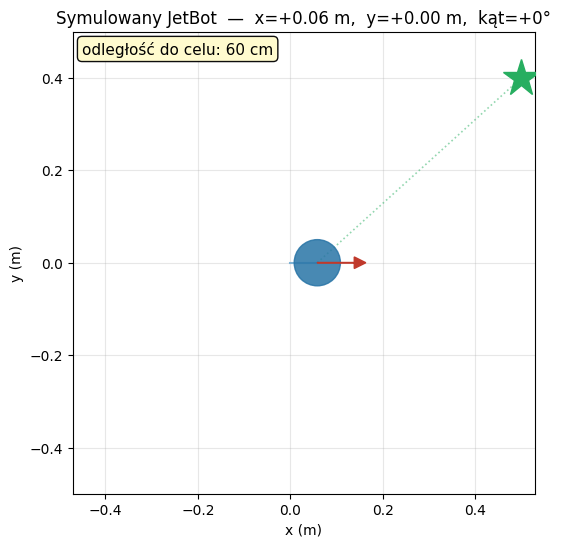

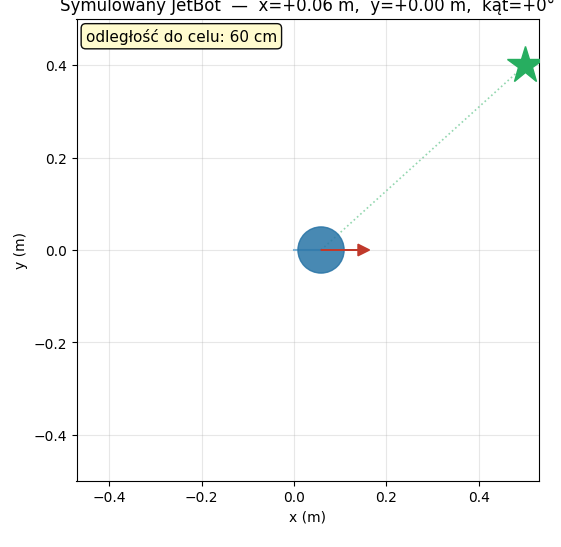

In [ ]:
from collections import deque


class TeleopLink(HasTraits):
    """Symulowane łącze radiowe między operatorem a robotem.

    `delay` to czas tam-i-z-powrotem w sekundach.

    Działa tak:
      - polecenie z `send(...)` dociera do robota po `delay/2` sekundach,
      - operator widzi to, co kamera robota nagrała `delay/2` sekund temu.
    """

    delay = Float(0.0)   # opóźnienie w obie strony (w sekundach)

    def __init__(self, robot):
        super().__init__()
        self.robot = robot
        self._cmd_queue     = deque()    # polecenia czekające na dostarczenie
        self._pose_history  = deque(maxlen=3000)
        self._observed_pose = robot.get_pose()
        self._running       = True
        threading.Thread(target=self._loop, daemon=True).start()

    @property
    def one_way(self):
        """Czas w jedną stronę = połowa czasu tam i z powrotem."""
        return self.delay / 2.0

    def send(self, action_fn):
        """Wysłanie polecenia. Wykona się dopiero po `one_way` sekundach."""
        arrive_at = time.time() + self.one_way
        self._cmd_queue.append((arrive_at, action_fn))

    def observed_pose(self):
        """Pozycja, jaką operator obecnie widzi (sprzed `one_way` sekund)."""
        return self._observed_pose

    def _loop(self):
        while self._running:
            now = time.time()

            # 1. Polecenia, które właśnie dotarły — wykonujemy je.
            #    Sprawdzamy CAŁĄ kolejkę, nie tylko pierwszy element. Dzięki
            #    temu, gdy zmniejszysz opóźnienie suwakiem (np. Mars → Ziemia),
            #    nowe, "szybkie" polecenia nie czekają w nieskończoność za
            #    starym poleceniem, które wciąż jeszcze "leci".
            still_waiting = deque()
            while self._cmd_queue:
                arrive_at, fn = self._cmd_queue.popleft()
                if arrive_at <= now:
                    try:
                        fn()
                    except Exception as e:
                        print("Błąd polecenia:", e)
                else:
                    still_waiting.append((arrive_at, fn))
            self._cmd_queue = still_waiting

            # 2. Zapisujemy bieżącą pozycję robota z aktualnym czasem.
            self._pose_history.append((now, self.robot.get_pose()))

            # 3. Operator "widzi" pozycję sprzed `one_way` sekund.
            cutoff = now - self.one_way
            best = self._observed_pose
            for t, pose in self._pose_history:
                if t <= cutoff:
                    best = pose
                else:
                    break
            self._observed_pose = best

            time.sleep(0.03)


Teraz tworzymy interfejs operatora. Zobaczysz dwa wykresy nakładające się
na siebie:

* **niebieski robot** ze strzałką — to, co widzi operator (z opóźnieniem),
* **szare kółko z przerywaną linią** — gdzie robot *naprawdę* jest w tej chwili,
* **zielona gwiazdka** — cel.

Im większe opóźnienie, tym bardziej te dwa kółka się od siebie oddalają.
To właśnie powód, dla którego sterowanie staje się trudne!


In [ ]:
# Tworzymy łącze i resetujemy robota.
robot.reset()
link = TeleopLink(robot)

# Suwak opóźnienia.
delay_slider = widgets.FloatSlider(
    description="opóźnienie (s, tam i z powrotem)",
    min=0.0, max=15.0, step=0.1, value=0.0,
    layout=widgets.Layout(width="520px"),
    style={"description_width": "initial"},
)
# Łączymy suwak z polem `delay` łącza (zmiana suwaka → zmiana opóźnienia).
traitlets.link((delay_slider, "value"), (link, "delay"))

# Przyciski-szybkie ustawienia: Ziemia / Księżyc / Mars.
preset = widgets.Layout(width="200px", height="40px")
btn_earth = widgets.Button(description="🌍 Ziemia (0 s)",        layout=preset)
btn_moon  = widgets.Button(description="🌕 Księżyc (2,6 s)",     layout=preset)
btn_mars  = widgets.Button(description="🔴 Mars (10 s, skrót)",  layout=preset)

btn_earth.on_click(lambda _: setattr(delay_slider, "value", 0.0))
btn_moon .on_click(lambda _: setattr(delay_slider, "value", 2.6))
btn_mars .on_click(lambda _: setattr(delay_slider, "value", 10.0))

# Te same przyciski sterowania co wcześniej — ale wysyłają polecenia
# przez łącze z opóźnieniem, a nie bezpośrednio do robota.
ctrl = widgets.Layout(width="90px", height="50px")
m_forward = widgets.Button(description="▲ przód", layout=ctrl)
m_back    = widgets.Button(description="▼ tył",   layout=ctrl)
m_left    = widgets.Button(description="◀ lewo",  layout=ctrl)
m_right   = widgets.Button(description="▶ prawo", layout=ctrl)
m_stop    = widgets.Button(description="■ STOP",  button_style="danger",  layout=ctrl)
m_reset   = widgets.Button(description="⟲ reset", button_style="warning", layout=ctrl)

m_forward.on_click(lambda _: link.send(lambda: robot.forward(0.3)))
m_back   .on_click(lambda _: link.send(lambda: robot.backward(0.3)))
m_left   .on_click(lambda _: link.send(lambda: robot.left(0.3)))
m_right  .on_click(lambda _: link.send(lambda: robot.right(0.3)))
m_stop   .on_click(lambda _: link.send(lambda: robot.stop()))

def _do_reset(_):
    """Reset czyści też kolejkę "lecących" poleceń, żeby zacząć od czysta."""
    link._cmd_queue.clear()
    robot.reset()
m_reset.on_click(_do_reset)


def show_delayed():
    """Rysuje to, co widzi operator (z opóźnieniem) plus 'duch' prawdziwej pozycji."""
    obs_x, obs_y, obs_th, obs_trail = link.observed_pose()
    act_x, act_y, act_th, act_trail = robot.get_pose()

    fig, ax = plt.subplots(figsize=(7, 7))

    # Prawdziwa droga robota — szary, ledwo widoczny.
    if len(act_trail) > 1:
        xs, ys = zip(*act_trail)
        ax.plot(xs, ys, "-", color="#bdbdbd", linewidth=1, label="prawdziwa droga")

    # Droga widziana przez operatora — niebieska, wyraźna.
    if len(obs_trail) > 1:
        xs, ys = zip(*obs_trail)
        ax.plot(xs, ys, "-", color="#7fb3d5", linewidth=1.6, label="co widzi operator")

    # "Duch" — prawdziwa pozycja robota teraz (szary, przerywany).
    ax.add_patch(mpatches.Circle((act_x, act_y), 0.05, fill=False,
                                 edgecolor="#7f8c8d", linewidth=2,
                                 linestyle="--", zorder=4, label="gdzie jest naprawdę"))

    # Robot, jakiego widzi operator (niebieski).
    ax.add_patch(mpatches.Circle((obs_x, obs_y), 0.05, color="#2874a6",
                                 alpha=0.85, zorder=5))
    ax.arrow(obs_x, obs_y,
             0.08 * math.cos(obs_th), 0.08 * math.sin(obs_th),
             head_width=0.025, head_length=0.025,
             fc="#c0392b", ec="#c0392b", zorder=6)

    # Cel — zielona gwiazdka.
    ax.plot(*TARGET, marker="*", color="#27ae60", markersize=28, zorder=7)

    # Odległość od celu (z perspektywy operatora — bo to ona się liczy).
    dist_cm = math.hypot(obs_x - TARGET[0], obs_y - TARGET[1]) * 100

    # Skalowanie wykresu.
    all_pts = list(obs_trail) + list(act_trail) + [(obs_x, obs_y), (act_x, act_y), TARGET]
    xs = [p[0] for p in all_pts]; ys = [p[1] for p in all_pts]
    cx, cy = (max(xs) + min(xs))/2, (max(ys) + min(ys))/2
    half = max(max(xs) - min(xs), max(ys) - min(ys), 1.0)/2 + 0.2
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")

    pending = len(link._cmd_queue)
    ax.set_title(
        f"opóźnienie: {link.delay:.1f} s  |  do celu: {dist_cm:.0f} cm  "
        f"|  poleceń w drodze: {pending}"
    )
    ax.legend(loc="upper right", fontsize=9)
    plt.show()


# Obszar do rysowania z odświeżaniem w tle.
delay_out = widgets.Output()

def _delay_refresh():
    while True:
        with delay_out:
            clear_output(wait=True)
            show_delayed()
        time.sleep(0.3)

threading.Thread(target=_delay_refresh, daemon=True).start()

# Wyświetlamy: suwak, przyciski-presety, pad sterowania + podgląd.
m_pad = widgets.VBox([
    m_forward,
    widgets.HBox([m_left, m_stop, m_right]),
    m_back,
    m_reset,
])

display(widgets.VBox([
    delay_slider,
    widgets.HBox([btn_earth, btn_moon, btn_mars]),
    widgets.HBox([m_pad, delay_out]),
]))

print("Zadanie: dotrzeć do zielonej gwiazdki na każdym z trzech opóźnień.")
print("Najpierw 🌍 Ziemia (0 s) — łatwe.")
print("Potem 🌕 Księżyc (2,6 s) — będziesz przesadzał i cofał.")
print("Na koniec 🔴 Mars (10 s) — spróbuj wymyślić strategię, np. krótkie")
print("    impulsy ruchu i długie czekanie na efekt.")


### 🎮 Konsola operatora — wersja interaktywna

Poniższa konsola łączy w jednym miejscu **podgląd robota i przyciski
sterowania** — jak prawdziwa konsola operatora łazika. Działa płynnie
w przeglądarce, więc od razu *czujesz* skutki opóźnienia.

**Jak używać:**

* Przyciskami (▲ ◀ ■ ▶ ▼) sterujesz robotem. **STOP** zatrzymuje silniki.
* Suwakiem albo przyciskami **🌍 Ziemia / 🌕 Księżyc / 🔴 Mars** ustawiasz
  opóźnienie łącza.
* 🔵 **niebieski robot** = to, co *widzisz* (z opóźnieniem).
  ⚪ **szary, przerywany** = gdzie robot jest *naprawdę* w tej chwili.
  ⭐ **gwiazdka** = cel.

**Zadanie:** dowieź robota do gwiazdki. Najpierw na Ziemi (łatwo!), potem
na Księżycu, a na końcu spróbuj na Marsie. Zwróć uwagę, jak bardzo niebieski
robot "spóźnia się" za szarym, gdy opóźnienie rośnie — i jak łatwo wtedy
przejechać cel.

> To ta sama fizyka, co w kodzie powyżej — tylko narysowana płynnie, żeby
> wygodniej się eksperymentowało. Pod spodem dzieje się dokładnie to samo:
> komenda leci do robota przez pół opóźnienia, a obraz wraca przez drugą
> połowę.


In [ ]:
# ---------------------------------------------------------------------
# Interaktywna konsola sterowania (płynna, działa w przeglądarce).
# Robot, jego ślad i przyciski są obok siebie. Cała fizyka i opóźnienie
# działają tak samo jak w klasie TeleopLink powyżej — tu po prostu
# rysujemy je płynnie 60 klatek na sekundę, dla wygody.
# ---------------------------------------------------------------------
from IPython.display import HTML, display

_console_html = r'''<div id="rover-console" style="font-family: system-ui, -apple-system, Segoe UI, Roboto, sans-serif; color:#1a1a1a; max-width:760px;">
  <div style="display:flex; flex-wrap:wrap; gap:18px; align-items:flex-start;">

    <!-- LEFT: robot view -->
    <div style="flex:0 0 auto;">
      <canvas id="rc-canvas" width="420" height="420"
              style="background:#f7f9fb; border:1px solid #d4dde4; border-radius:10px;"></canvas>
      <div id="rc-status" style="margin-top:8px; font-size:13px; line-height:1.5; color:#33414c;"></div>
    </div>

    <!-- RIGHT: controls -->
    <div style="flex:1 1 220px; min-width:220px;">
      <div style="font-weight:600; margin-bottom:6px;">Sterowanie</div>
      <div style="display:grid; grid-template-columns:repeat(3,64px); grid-gap:6px; justify-content:start;">
        <div></div>
        <button class="rc-btn" data-cmd="forward">▲</button>
        <div></div>
        <button class="rc-btn" data-cmd="left">◀</button>
        <button class="rc-btn rc-stop" data-cmd="stop">STOP</button>
        <button class="rc-btn" data-cmd="right">▶</button>
        <div></div>
        <button class="rc-btn" data-cmd="back">▼</button>
        <div></div>
      </div>
      <button class="rc-btn rc-reset" data-cmd="reset"
              style="width:200px; margin-top:6px;">⟲ reset</button>

      <div style="font-weight:600; margin:16px 0 6px;">Opóźnienie łącza</div>
      <input id="rc-delay" type="range" min="0" max="15" step="0.1" value="0"
             style="width:200px;">
      <div id="rc-delay-label" style="font-size:13px; margin-top:2px;"></div>
      <div style="display:flex; gap:6px; margin-top:8px; flex-wrap:wrap;">
        <button class="rc-preset" data-delay="0">🌍 Ziemia</button>
        <button class="rc-preset" data-delay="2.6">🌕 Księżyc</button>
        <button class="rc-preset" data-delay="10">🔴 Mars</button>
      </div>

      <div style="margin-top:14px; font-size:12px; color:#667; line-height:1.5;">
        🔵 to, co widzisz (z opóźnieniem)<br>
        ⚪ gdzie robot <i>naprawdę</i> jest<br>
        ⭐ cel
      </div>
    </div>
  </div>
</div>

<style>
  #rover-console .rc-btn {
    height:48px; border:1px solid #c3ccd4; border-radius:8px; background:#fff;
    font-size:16px; cursor:pointer; transition:background .08s, transform .05s;
    color:#1a1a1a;
  }
  #rover-console .rc-btn:hover   { background:#eef3f7; }
  #rover-console .rc-btn:active  { transform:scale(0.94); background:#dde7ee; }
  #rover-console .rc-stop  { background:#c0392b; color:#fff; border-color:#a5301f; font-size:13px; font-weight:600; }
  #rover-console .rc-stop:hover  { background:#a5301f; }
  #rover-console .rc-reset { background:#f0ad4e; color:#3a2c00; border-color:#d9982f; font-weight:600; }
  #rover-console .rc-reset:hover { background:#d9982f; }
  #rover-console .rc-preset {
    padding:6px 10px; border:1px solid #c3ccd4; border-radius:8px; background:#fff;
    cursor:pointer; font-size:13px; color:#1a1a1a;
  }
  #rover-console .rc-preset:hover { background:#eef3f7; }
</style>

<script>
(function () {
  "use strict";
  var root = document.getElementById("rover-console");
  if (!root) return;
  var canvas = root.querySelector("#rc-canvas");
  var ctx = canvas.getContext("2d");
  var W = canvas.width, H = canvas.height;

  // ---- Physics constants (identical to the Python Robot) ----
  var WHEEL_BASE = 0.12, MAX_SPEED = 0.30, DRIVE = 0.30;
  var TARGET = { x: 0.5, y: 0.4 }, TOL = 0.12;

  var S = {
    x: 0, y: 0, theta: 0, vL: 0, vR: 0,
    delay: 0.0, cmdQueue: [], history: [],
    trueTrail: [], obsTrail: [],
    view: { cx: 0.25, cy: 0.2, scale: 150 }, lastT: null
  };
  function oneWay() { return S.delay / 2.0; }

  function applyCommand(type) {
    if (type === "forward")    { S.vL = DRIVE;  S.vR = DRIVE; }
    else if (type === "back")  { S.vL = -DRIVE; S.vR = -DRIVE; }
    else if (type === "left")  { S.vL = -DRIVE; S.vR = DRIVE; }
    else if (type === "right") { S.vL = DRIVE;  S.vR = -DRIVE; }
    else if (type === "stop")  { S.vL = 0;      S.vR = 0; }
  }
  function sendCommand(type, now) {
    if (type === "reset") { resetAll(); return; }
    S.cmdQueue.push({ arriveAt: now + oneWay(), type: type });
  }
  function resetAll() {
    S.x = 0; S.y = 0; S.theta = 0; S.vL = 0; S.vR = 0;
    S.cmdQueue = []; S.history = []; S.trueTrail = []; S.obsTrail = [];
  }
  // Deliver every command whose own arrival time has passed (no head-of-line
  // blocking — matches the patched Python TeleopLink).
  function deliverCommands(now) {
    var still = [];
    for (var i = 0; i < S.cmdQueue.length; i++) {
      var c = S.cmdQueue[i];
      if (c.arriveAt <= now) applyCommand(c.type);
      else still.push(c);
    }
    S.cmdQueue = still;
  }
  function stepPhysics(dt) {
    var vL = S.vL * MAX_SPEED, vR = S.vR * MAX_SPEED;
    var v = 0.5 * (vL + vR), omega = (vR - vL) / WHEEL_BASE;
    S.theta += omega * dt;
    S.x += v * Math.cos(S.theta) * dt;
    S.y += v * Math.sin(S.theta) * dt;
  }
  function observedPose(now) {
    var cutoff = now - oneWay(), best = null;
    for (var i = 0; i < S.history.length; i++) {
      if (S.history[i].t <= cutoff) best = S.history[i];
      else break;
    }
    if (!best) best = S.history.length ? S.history[0] : { x: 0, y: 0, theta: 0 };
    return best;
  }
  function updateView(obs) {
    var pts = [{ x: 0, y: 0 }, TARGET, { x: S.x, y: S.y }, { x: obs.x, y: obs.y }];
    var minX = pts[0].x, maxX = pts[0].x, minY = pts[0].y, maxY = pts[0].y;
    for (var i = 1; i < pts.length; i++) {
      if (pts[i].x < minX) minX = pts[i].x; if (pts[i].x > maxX) maxX = pts[i].x;
      if (pts[i].y < minY) minY = pts[i].y; if (pts[i].y > maxY) maxY = pts[i].y;
    }
    var span = Math.max(maxX - minX, maxY - minY, 1.4) + 0.4;
    var ts = (W - 60) / span, tcx = (minX + maxX) / 2, tcy = (minY + maxY) / 2;
    S.view.scale += (ts - S.view.scale) * 0.08;
    S.view.cx += (tcx - S.view.cx) * 0.08;
    S.view.cy += (tcy - S.view.cy) * 0.08;
  }
  function sx(wx) { return W / 2 + (wx - S.view.cx) * S.view.scale; }
  function sy(wy) { return H / 2 - (wy - S.view.cy) * S.view.scale; }

  function drawArrow(x, y, theta, color) {
    var len = 0.10 * S.view.scale;
    var ex = sx(x) + Math.cos(-theta) * len, ey = sy(y) + Math.sin(-theta) * len;
    ctx.strokeStyle = color; ctx.fillStyle = color; ctx.lineWidth = 2.5;
    ctx.beginPath(); ctx.moveTo(sx(x), sy(y)); ctx.lineTo(ex, ey); ctx.stroke();
    var a = Math.atan2(ey - sy(y), ex - sx(x));
    ctx.beginPath();
    ctx.moveTo(ex, ey);
    ctx.lineTo(ex - 8 * Math.cos(a - 0.4), ey - 8 * Math.sin(a - 0.4));
    ctx.lineTo(ex - 8 * Math.cos(a + 0.4), ey - 8 * Math.sin(a + 0.4));
    ctx.closePath(); ctx.fill();
  }
  function drawTrail(trail, color, width) {
    if (trail.length < 2) return;
    ctx.strokeStyle = color; ctx.lineWidth = width; ctx.beginPath();
    ctx.moveTo(sx(trail[0].x), sy(trail[0].y));
    for (var i = 1; i < trail.length; i++) ctx.lineTo(sx(trail[i].x), sy(trail[i].y));
    ctx.stroke();
  }

  function render(now) {
    var obs = observedPose(now);
    updateView(obs);
    ctx.clearRect(0, 0, W, H);

    // grid
    ctx.strokeStyle = "#e6ecf1"; ctx.lineWidth = 1;
    var step = 0.25 * S.view.scale;
    for (var gx = (W / 2 - S.view.cx * S.view.scale) % step; gx < W; gx += step) {
      ctx.beginPath(); ctx.moveTo(gx, 0); ctx.lineTo(gx, H); ctx.stroke();
    }
    for (var gy = (H / 2 + S.view.cy * S.view.scale) % step; gy < H; gy += step) {
      ctx.beginPath(); ctx.moveTo(0, gy); ctx.lineTo(W, gy); ctx.stroke();
    }

    drawTrail(S.trueTrail, "#cfd6dc", 1.5);       // true path, faint
    drawTrail(S.obsTrail, "#7fb3d5", 2);          // operator's path, blue

    // target star
    var tx = sx(TARGET.x), ty = sy(TARGET.y);
    ctx.fillStyle = "#27ae60";
    ctx.beginPath();
    for (var k = 0; k < 10; k++) {
      var r = (k % 2 === 0) ? 12 : 5, ang = Math.PI / 5 * k - Math.PI / 2;
      var px = tx + r * Math.cos(ang), py = ty + r * Math.sin(ang);
      if (k === 0) ctx.moveTo(px, py); else ctx.lineTo(px, py);
    }
    ctx.closePath(); ctx.fill();

    // true position — grey dashed ghost
    ctx.setLineDash([4, 3]); ctx.strokeStyle = "#8b97a1"; ctx.lineWidth = 2;
    ctx.beginPath(); ctx.arc(sx(S.x), sy(S.y), 0.05 * S.view.scale, 0, 2 * Math.PI); ctx.stroke();
    ctx.setLineDash([]);
    drawArrow(S.x, S.y, S.theta, "#aeb7bf");

    // operator's view — solid blue
    ctx.fillStyle = "#2874a6";
    ctx.beginPath(); ctx.arc(sx(obs.x), sy(obs.y), 0.05 * S.view.scale, 0, 2 * Math.PI); ctx.fill();
    drawArrow(obs.x, obs.y, obs.theta, "#c0392b");

    // status text
    var obsDist = Math.hypot(obs.x - TARGET.x, obs.y - TARGET.y) * 100;
    var trueDist = Math.hypot(S.x - TARGET.x, S.y - TARGET.y) * 100;
    var inflight = S.cmdQueue.length;
    var msg = "";
    if (trueDist < TOL * 100) msg = '<span style="color:#27ae60; font-weight:600;">🎯 Robot dotarł do celu!</span><br>';
    statusEl.innerHTML = msg +
      "do celu (Twój widok): <b>" + obsDist.toFixed(0) + " cm</b>" +
      "  ·  naprawdę: " + trueDist.toFixed(0) + " cm<br>" +
      "poleceń w drodze: <b>" + inflight + "</b>";
  }

  var statusEl = root.querySelector("#rc-status");
  var delaySlider = root.querySelector("#rc-delay");
  var delayLabel = root.querySelector("#rc-delay-label");

  function updateDelayLabel() {
    var d = S.delay, ow = d / 2;
    var planet = d === 0 ? "Ziemia (na żywo)"
               : (Math.abs(d - 2.6) < 0.05 ? "Księżyc"
               : (Math.abs(d - 10) < 0.05 ? "Mars (skrót)" : "własne"));
    delayLabel.innerHTML = "tam i z powrotem: <b>" + d.toFixed(1) + " s</b> " +
      "(w jedną stronę " + ow.toFixed(1) + " s) — " + planet;
  }

  // wire up buttons
  root.querySelectorAll(".rc-btn").forEach(function (b) {
    b.addEventListener("click", function () {
      sendCommand(b.getAttribute("data-cmd"), performance.now() / 1000);
    });
  });
  root.querySelectorAll(".rc-preset").forEach(function (b) {
    b.addEventListener("click", function () {
      S.delay = parseFloat(b.getAttribute("data-delay"));
      delaySlider.value = S.delay; updateDelayLabel();
    });
  });
  delaySlider.addEventListener("input", function () {
    S.delay = parseFloat(delaySlider.value); updateDelayLabel();
  });
  updateDelayLabel();

  // main loop
  function frame(ts) {
    var now = ts / 1000;
    if (S.lastT === null) S.lastT = now;
    var dt = Math.min(now - S.lastT, 0.1); S.lastT = now;

    deliverCommands(now);
    stepPhysics(dt);
    S.history.push({ t: now, x: S.x, y: S.y, theta: S.theta });
    if (S.history.length > 4000) S.history.shift();

    // record trails (throttle a bit)
    var lastTrue = S.trueTrail[S.trueTrail.length - 1];
    if (!lastTrue || Math.hypot(S.x - lastTrue.x, S.y - lastTrue.y) > 0.004) {
      S.trueTrail.push({ x: S.x, y: S.y });
      if (S.trueTrail.length > 4000) S.trueTrail.shift();
    }
    var obs = observedPose(now);
    var lastObs = S.obsTrail[S.obsTrail.length - 1];
    if (!lastObs || Math.hypot(obs.x - lastObs.x, obs.y - lastObs.y) > 0.004) {
      S.obsTrail.push({ x: obs.x, y: obs.y });
      if (S.obsTrail.length > 4000) S.obsTrail.shift();
    }

    render(now);
    requestAnimationFrame(frame);
  }
  requestAnimationFrame(frame);
})();
</script>'''

display(HTML(_console_html))

### Pytania do przemyślenia 🤔

Po krótkiej zabawie z opóźnieniem zastanów się:

1. **Co się dzieje, kiedy klikniesz STOP?** Czy robot zatrzymuje się od razu?
   Dlaczego nie?
2. Spróbuj **policzyć "przejechany dystans nadmiarowy"** — o ile metrów
   robot przejedzie *po* tym, jak naciśniesz STOP, przy opóźnieniu 10 s
   i prędkości 0,3 (czyli 0,09 m/s)? Sprawdź wynik na wykresie.
3. **Dlaczego prawdziwe łaziki marsjańskie są** *autonomiczne* (same
   podejmują decyzje), a nie po prostu szybsze w reakcji?
4. Co byś **dodał** do takiego robota, żeby mniej polegał na operatorze?
   (Podpowiedź: czujniki, kamery, *sztuczna inteligencja*…)

To są dokładnie te same problemy, nad którymi pracują inżynierowie NASA
i ESA. Witaj w robotyce kosmicznej!


## 13. Autonomia — gdy robot myśli sam 🧠

Wniosek z poprzedniej sekcji jest twardy: **przy dużym opóźnieniu nie da
się sterować robotem joystickiem**. Klikasz coś, a efekt widzisz dopiero
po kilku sekundach (Księżyc), kilku minutach (Mars), albo godzinach
(misje do zewnętrznych planet).

Co więc robi NASA, żeby łazik w ogóle dało się prowadzić? Daje mu **własny
mózg**. Łazik dostaje cel — "dojedź do tamtego kamienia" — i sam decyduje,
jak go osiągnąć. Decyzje są podejmowane **lokalnie, na pokładzie robota**,
więc opóźnienie sygnału do Ziemi **w ogóle nie ma znaczenia**.

To nazywa się **autonomia**. Curiosity i Perseverance używają systemu
zwanego *AutoNav*: same patrzą kamerami, same omijają kamienie, same
planują ścieżkę. Operatorzy z Ziemi mówią im **gdzie**, a łazik wymyśla
**jak**.

### Morał z całej historii 📜

To, że łaziki marsjańskie tak dobrze działają, **nie wynika z tego, że
mamy szybkie radio** (nie mamy — prędkość światła to twarda granica
fizyki). Wynika z tego, że **przenieśliśmy mózg z Ziemi do robota**.

Ewolucja sterowania robotem:

| Sposób | Kto decyduje | Kiedy się używa |
|---|---|---|
| **Bezpośrednie sterowanie** (sekcje 1-10) | człowiek, na żywo | gdy robot jest tuż obok |
| **Teleoperacja** (sekcja 11) | człowiek, przez łącze | gdy robot jest "daleko, ale nie aż tak" — dron, robot chirurgiczny |
| **Teleoperacja z opóźnieniem** (sekcja 12) | człowiek + buforowanie | krótkie misje księżycowe; bardzo trudna sztuka |
| **Autonomia** (ta sekcja) | **sam robot** | wszędzie, gdzie opóźnienie jest duże lub gdzie potrzeba szybkich reakcji — łaziki, drony bojowe, samochody autonomiczne |

**AutoNav**, systemu, który nawiguje łaziki Curiosity i Perseverance po Marsie. Prawdziwy AutoNav:

* analizuje obraz z kamer i **rozpoznaje przeszkody** (kamienie, kratery),
* buduje **mapę terenu 3D** i planuje na niej ścieżkę,
* sprawdza, czy podłoże jest stabilne (nie chcemy ugrzęznąć w piasku),
* mierzy ślizg kół i sam to korygował.


## 14. Podsumowanie

Brawo! Właśnie **sterowałeś robotem z poziomu przeglądarki** — używając
tych samych poleceń, których używałbyś przy prawdziwym robocie JetBot.
Gdybyś kiedyś dostał taki robot do ręki, wystarczyłoby w jednej linijce
zamienić nasz symulator na prawdziwy:

```python
# zamiast:  robot = Robot()
from jetbot import Robot
robot = Robot()
```

...a cała reszta tego notatnika działałaby tak samo, tylko z prawdziwym
sprzętem.

---

### Gdzie to uruchomić za darmo

| Platforma | Zalety | Na co uważać |
|---|---|---|
| **Google Colab** | Bez instalacji, wystarczy konto Google. Łatwe dla całej klasy. | Niektóre widżety wymagają włączenia obsługi (już zrobione w sekcji 1). |
| **Kaggle Notebooks** | Darmowe, bez instalacji, zapisuje notatniki. | Suwaki czasem działają trochę wolniej. |
| **mybinder.org (Binder)** | Otwiera dowolne repo z GitHuba jako gotowe środowisko — **bez logowania**. Świetne dla nauczyciela: udostępniasz jeden link i cała klasa ma to samo. | Sesja jest tymczasowa — po zamknięciu zmiany znikają. |
| **Deepnote** | Ładny interfejs, można pracować razem na jednym notatniku jak w Google Docs. | Ograniczone darmowe godziny obliczeniowe. |
| **JupyterLite** | Działa **całkowicie w przeglądarce**, bez serwera, bez logowania. | Brak wątków (threads) — fizykę robota trzeba by przepisać inaczej. |
| **GitHub Codespaces** | Pełen VS Code w przeglądarce; **darmowe godziny dla uczniów** w ramach GitHub Student Pack. | Wymaga konta GitHub. |

**Dla klasy szkolnej najlepsze są zwykle Colab albo Binder.** Binder ma tę
zaletę, że nauczyciel publikuje jeden link, a cała klasa wchodzi w to samo
środowisko — zero instalacji.

### Co dalej?

Gdy już opanujesz ten notatnik, możesz spróbować:

* dodać **przeszkody** i napisać kod, który robot omija ściany,
* dodać symulowaną **kamerę** i nauczyć robota jeździć po linii,
* zbudować **labirynt** i nauczyć robota go przechodzić,
* rozbudować kontroler autonomiczny z sekcji 13: dodać omijanie
  przeszkód albo sekwencję wielu celów do odwiedzenia,
* wymienić rysowanie na coś szybszego (np. `ipycanvas`) gdy chcesz mieć
  szybsze animacje.

Powodzenia, mali rocket scientists! 🚀
